<a href="https://colab.research.google.com/github/BhavyaKansal20/DeepLearning/blob/main/MNIST_ANN_vs_Classical_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training images shape:", X_train_full.shape)
print("Training labels shape:", y_train_full.shape)
print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


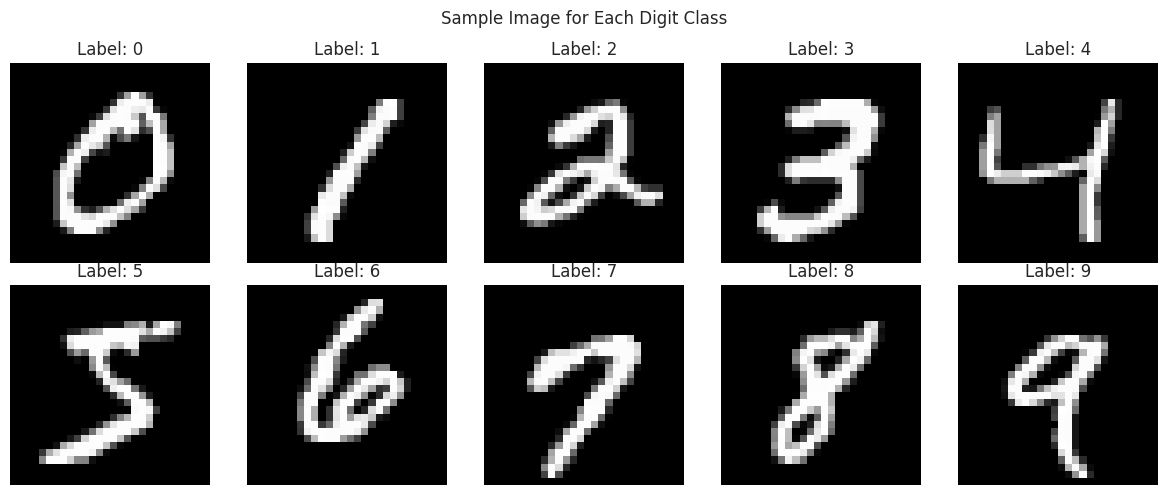

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    idx = np.where(y_train_full == digit)[0][0]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(X_train_full[idx], cmap="gray")
    ax.set_title(f"Label: {digit}")
    ax.axis("off")
plt.suptitle("Sample Image for Each Digit Class")
plt.tight_layout()
plt.show()


/tmp/ipykernel_3037/31438038.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_full, palette="viridis")


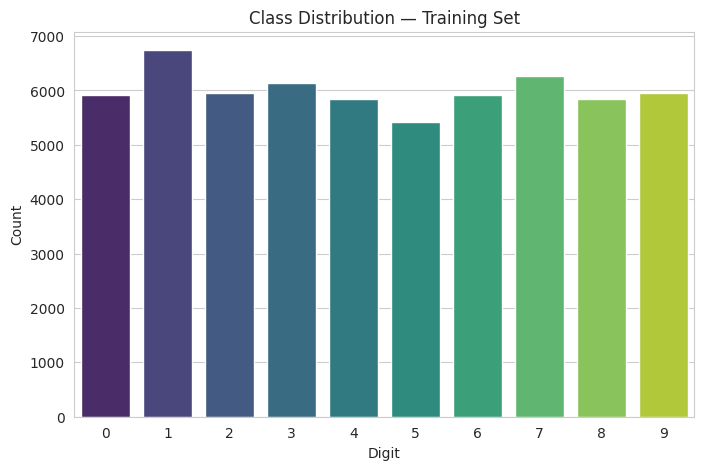

Pixel value range: 0 to 255


In [ ]:
plt.figure()
sns.countplot(x=y_train_full, palette="viridis")
plt.title("Class Distribution — Training Set")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

print("Pixel value range:", X_train_full.min(), "to", X_train_full.max())


In [ ]:
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Classical ML models ke liye flattened version
X_train_flat = X_train_full.reshape(len(X_train_full), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print("ANN input shape (per image):", X_train_full.shape[1:])
print("Flattened input shape (per image):", X_train_flat.shape[1:])


ANN input shape (per image): (28, 28)
Flattened input shape (per image): (784,)


In [ ]:
ann_model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", mode="max", patience=5, restore_best_weights=True
)

start_time = time.time()
history = ann_model.fit(
    X_train_full, y_train_full,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)
ann_train_time = time.time() - start_time
print(f"ANN training time: {ann_train_time:.2f} seconds")


Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8772 - loss: 0.4172 - val_accuracy: 0.9597 - val_loss: 0.1424
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9467 - loss: 0.1789 - val_accuracy: 0.9692 - val_loss: 0.1020
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9609 - loss: 0.1315 - val_accuracy: 0.9750 - val_loss: 0.0885
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9665 - loss: 0.1075 - val_accuracy: 0.9760 - val_loss: 0.0829
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9723 - loss: 0.0892 - val_accuracy: 0.9783 - val_loss: 0.0762
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9752 - loss: 0.0771 - val_accuracy: 0.9790 - val_loss: 0.0705
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9786 - loss: 0.0684 - val_accuracy: 0.9788 - val_loss: 0.0694
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9799 - loss: 0.0629 - val_accuracy: 0.

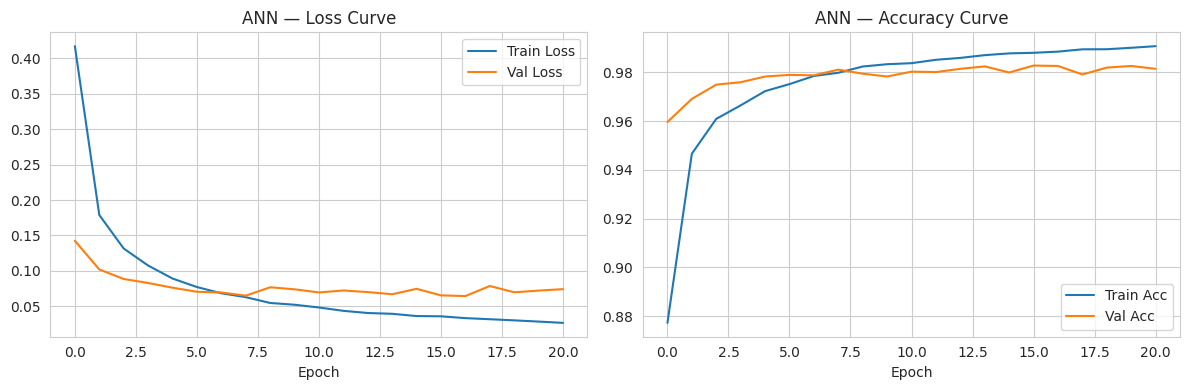

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("ANN — Loss Curve"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Acc")
axes[1].plot(history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("ANN — Accuracy Curve"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
y_pred_ann = np.argmax(ann_model.predict(X_test, verbose=0), axis=1)
ann_acc = accuracy_score(y_test, y_pred_ann)

print("ANN Test Accuracy:", ann_acc)
print("\nClassification Report (ANN):\n")
print(classification_report(y_test, y_pred_ann))


ANN Test Accuracy: 0.98

Classification Report (ANN):

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.99      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.97      0.99      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.97      0.98      0.97      1028
           8       0.98      0.97      0.97       974
           9       0.99      0.96      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



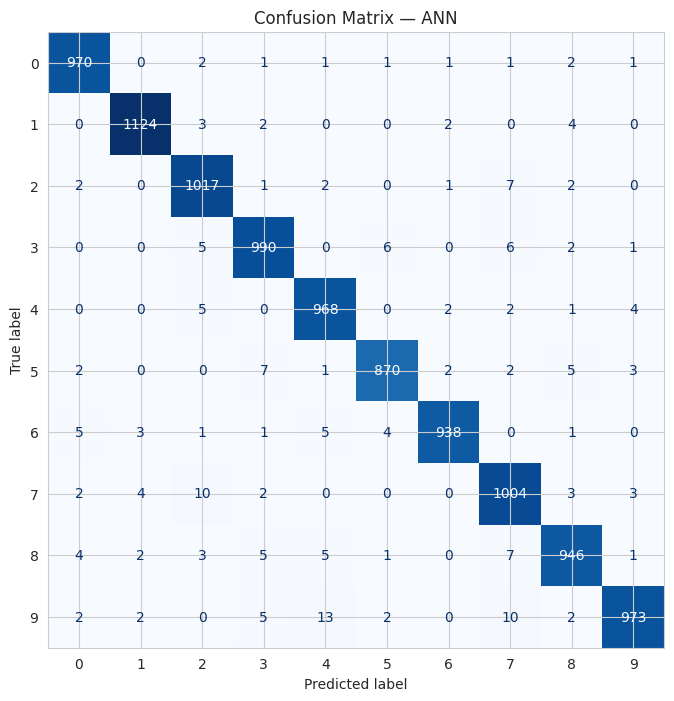

In [ ]:
cm_ann = confusion_matrix(y_test, y_pred_ann)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=range(10))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Confusion Matrix — ANN")
plt.show()


In [ ]:
log_reg = LogisticRegression(max_iter=200, solver="lbfgs", n_jobs=-1)

start_time = time.time()
log_reg.fit(X_train_flat, y_train_full)
lr_train_time = time.time() - start_time
print(f"Logistic Regression training time: {lr_train_time:.2f} seconds")

y_pred_lr = log_reg.predict(X_test_flat)
lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Test Accuracy:", lr_acc)
print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_lr))


Logistic Regression training time: 59.65 seconds
Logistic Regression Test Accuracy: 0.9268

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.91      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.89      0.88      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.91      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



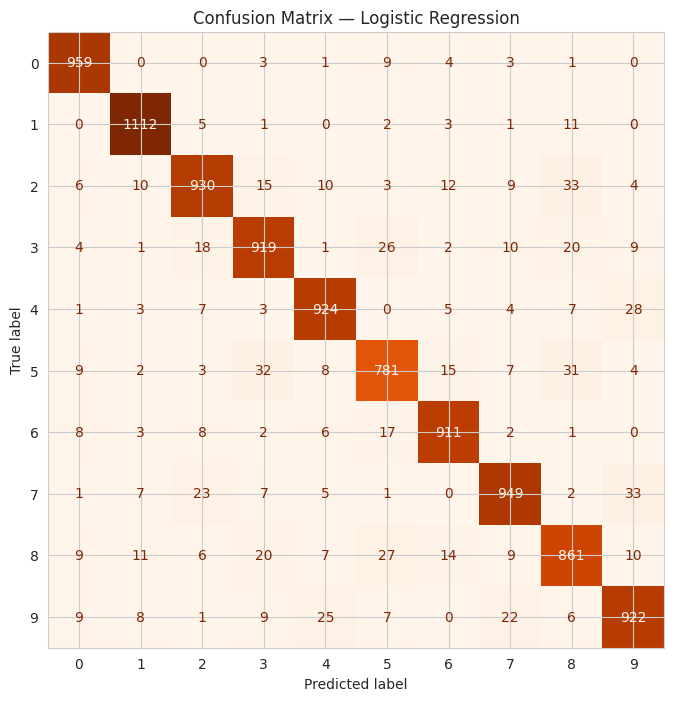

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=range(10))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Oranges", ax=ax, colorbar=False)
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


In [ ]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)

start_time = time.time()
rf_clf.fit(X_train_flat, y_train_full)
rf_train_time = time.time() - start_time
print(f"Random Forest training time: {rf_train_time:.2f} seconds")

y_pred_rf = rf_clf.predict(X_test_flat)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Test Accuracy:", rf_acc)
print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf))


Random Forest training time: 47.62 seconds
Random Forest Test Accuracy: 0.9704

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



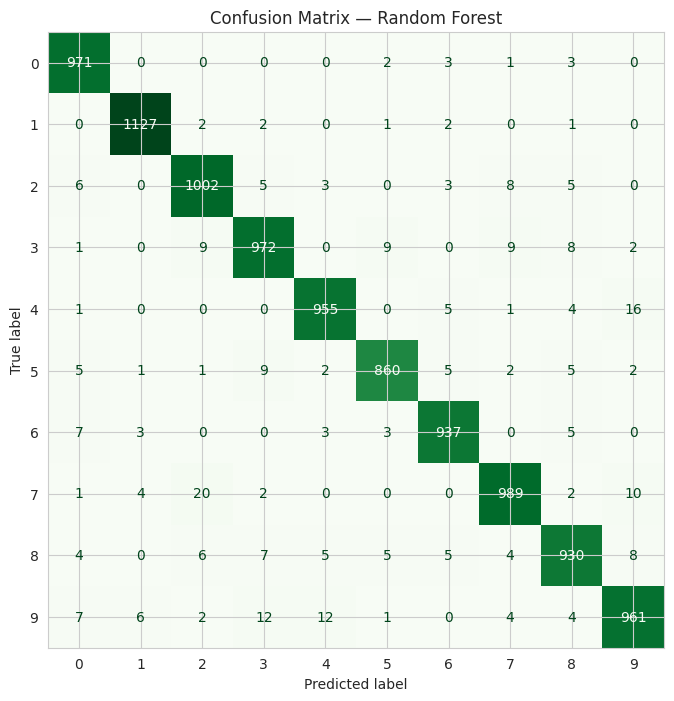

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=range(10))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Greens", ax=ax, colorbar=False)
plt.title("Confusion Matrix — Random Forest")
plt.show()


In [ ]:
def get_metrics(y_true, y_pred, model_name, train_time):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro"
    )
    acc = accuracy_score(y_true, y_pred)
    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision (macro)": round(precision, 4),
        "Recall (macro)": round(recall, 4),
        "F1-score (macro)": round(f1, 4),
        "Training Time (s)": round(train_time, 2)
    }

results = [
    get_metrics(y_test, y_pred_ann, "Feedforward ANN", ann_train_time),
    get_metrics(y_test, y_pred_lr, "Logistic Regression", lr_train_time),
    get_metrics(y_test, y_pred_rf, "Random Forest", rf_train_time),
]

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro),Training Time (s)
0,Feedforward ANN,0.9800,0.9801,0.9798,0.9799,68.10
1,Logistic Regression,0.9268,0.9258,0.9258,0.9257,59.65
2,Random Forest,0.9704,0.9703,0.9701,0.9702,47.62


/tmp/ipykernel_3037/4221428979.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, ax=ax, palette="viridis")
/tmp/ipykernel_3037/4221428979.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, ax=ax, palette="viridis")
/tmp/ipykernel_3037/4221428979.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, ax=ax, palette="viridis")


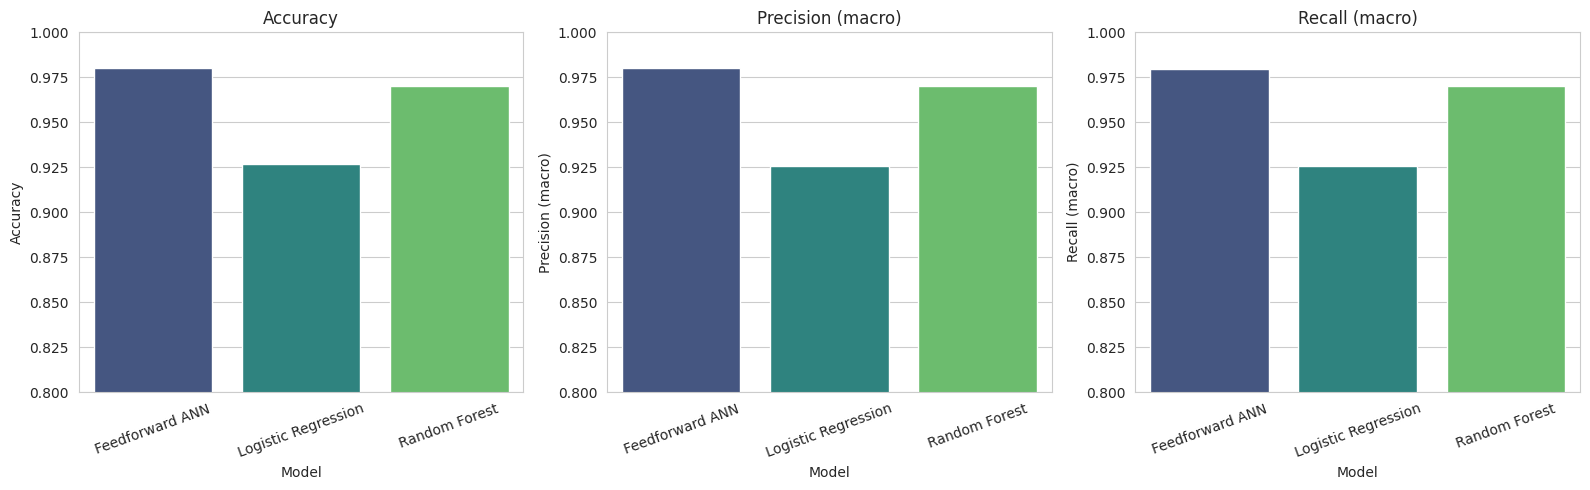

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ["Accuracy", "Precision (macro)", "Recall (macro)"]

for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(x="Model", y=metric, data=results_df, ax=ax, palette="viridis")
    ax.set_title(metric)
    ax.set_ylim(0.8, 1.0)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


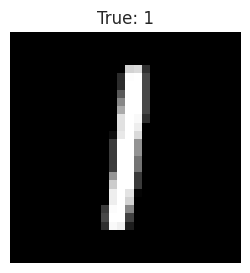

ANN Prediction:                 1
Logistic Regression Prediction: 1
Random Forest Prediction:       1


In [ ]:
sample_idx = np.random.randint(0, len(X_test))
sample_image = X_test[sample_idx]
true_label = y_test[sample_idx]

ann_pred = np.argmax(ann_model.predict(sample_image.reshape(1, 28, 28), verbose=0))
lr_pred = log_reg.predict(sample_image.reshape(1, -1))[0]
rf_pred = rf_clf.predict(sample_image.reshape(1, -1))[0]

plt.figure(figsize=(3, 3))
plt.imshow(sample_image, cmap="gray")
plt.title(f"True: {true_label}")
plt.axis("off")
plt.show()

print(f"ANN Prediction:                 {ann_pred}")
print(f"Logistic Regression Prediction: {lr_pred}")
print(f"Random Forest Prediction:       {rf_pred}")


Label: 5
Matrix Shape: (28, 28)

Pixel Matrix (raw values 0-255):

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0

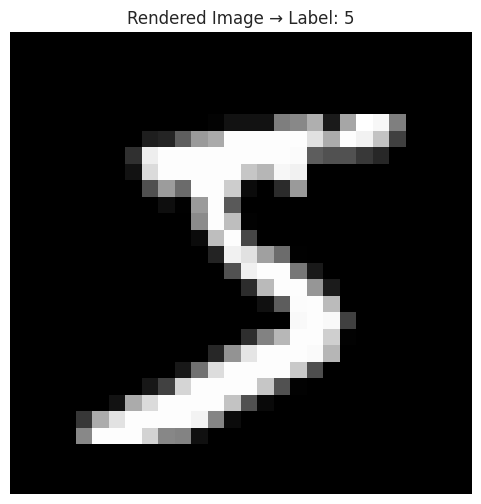

In [ ]:

(X_train, y_train), (_, _) = keras.datasets.mnist.load_data()

index = 0
image = X_train[index]
label = y_train[index]

np.set_printoptions(linewidth=200, threshold=np.inf)
print(f"Label: {label}")
print(f"Matrix Shape: {image.shape}\n")
print("Pixel Matrix (raw values 0-255):\n")
print(image)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title(f"Rendered Image → Label: {label}")
plt.axis("off")
plt.show()